In [ ]:
import pandas as pd
from code.preprocessing import PDBpreprocessing

raw_data = pd.read_csv("LP_PDBBind.csv")

preprocessed_data = PDBpreprocessing(raw_data, category= None, variable='both', keep_protein_chain=False, log_transform=True)
print(preprocessed_data.shape)
preprocessed_data.head()

✅ Cleaned dataset shape: (19121, 2)
   Dropped rows with None/NaN in ['smiles', 'target']
(19121, 2)


,smiles,target
0,CSc1ccccc1[C@H]1CCCN1C(=O)CNC(=O)NCc1ccc2c(c1)...,1.796016
1,O=C([O-])CCC[N@H+]1CCC[C@H]1COc1ccc(Oc2ccc(Cl)...,3.223619
2,CCC(CC)O[C@@H]1C[C@H](C(=O)[O-])C[C@H]([NH3+])...,-1.473654
3,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,11.121486
4,[NH3+][C@@H](C[C@]1(C(=O)[O-])C[C@H]2OCC[C@@H]...,5.134765


Start : Use the headers as categories (group all the small categories)
Ask if there are libraries that do protein fingerprints
Then try to caracterise the amino acid chain in order to use it as an input
Then maybe explore the alphafold API in order to do the same thing


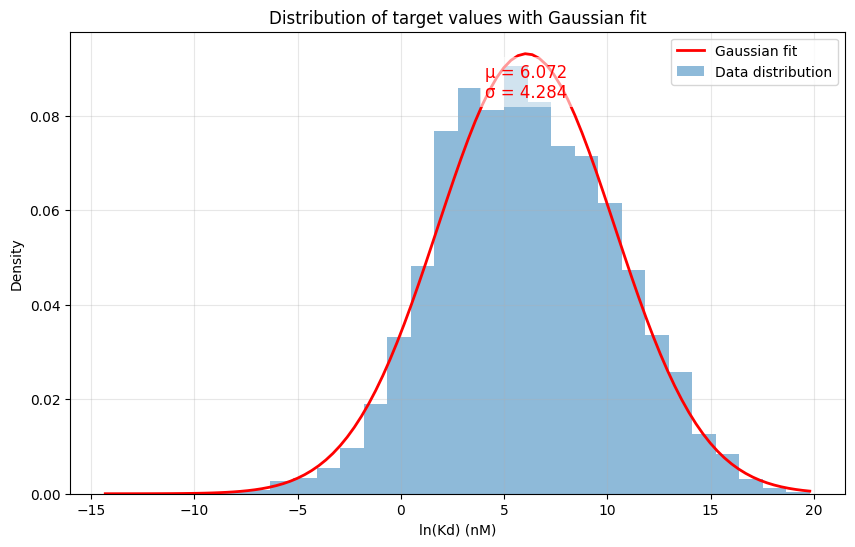

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Extract data
data = preprocessed_data['target'].dropna().values

# Compute stats
mean = np.mean(data)
std = np.std(data)

# Histogram setup
X_plot = np.linspace(data.min(), data.max(), 100)
Y_hist, bin_edges = np.histogram(data, bins=30, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Gaussian (normal) fit
Y_gauss = norm.pdf(X_plot, mean, std)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(bin_centers, Y_hist, width=np.diff(bin_edges), alpha=0.5, label='Data distribution')
plt.plot(X_plot, Y_gauss, 'r-', linewidth=2, label='Gaussian fit')

# Add text for mean and std
plt.text(mean, max(Y_gauss)*0.9, f"μ = {mean:.3f}\nσ = {std:.3f}", 
         fontsize=12, color='red', ha='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.xlabel('ln(Kd) (nM)')
plt.ylabel('Density')
plt.title('Distribution of target values with Gaussian fit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In order to have a better distribution we'll use the logarithm of the Kd Values :)

During the preprocessing it appeared that some of the data points were missing the smiles. 

Now that we have a propper subset of preprocessed data, we will train several regression models (Graph Neural Network and Random Forest Regression) and optimize their hyperparameters in order to optimize the prediction of the Kd values. The models will all be trained with the same fingerprints extracted from the SMILES.

Random Forest Optimization

In [ ]:
# Fingerprint extraction and Random Forest Regression with hyperparameter optimization and standardized data
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

r_fingerprint=2
Bits_fingerprint=2048

# Extract Morgan fingerprints from SMILES
def smiles_to_fingerprint(smiles, radius=r_fingerprint, nBits=Bits_fingerprint):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(nBits)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
    return np.array(fp)

X = np.array([smiles_to_fingerprint(s) for s in preprocessed_data['smiles']])
y = preprocessed_data['target'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': np.linspace(20, 100, 4).astype(int),
    'max_depth': np.linspace(100, 200, 4).astype(int),
    'min_samples_split': [2]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, return_train_score=True)
grid_search.fit(X_train, y_train)

# Best model and predictions
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MSE (standardized): {mse:.2f}")
print(f"Test R2 (standardized): {r2:.2f}")

# Prepare matrix for heatmap plots
results = grid_search.cv_results_
df_results = pd.DataFrame(results)
df_results['max_depth'] = df_results['param_max_depth'].fillna(-1).astype(int)
df_results['n_estimators'] = df_results['param_n_estimators'].astype(int)

# Choose a fixed value for min_samples_split, e.g. 2
fixed_split = 2
filtered = df_results[df_results['param_min_samples_split'] == fixed_split]

# Calculate MSE and R2 for each parameter combination
mse_matrix = filtered.pivot(index='max_depth', columns='n_estimators', values='mean_test_score')
r2_matrix = filtered.pivot(index='max_depth', columns='n_estimators', values='mean_train_score')

# Show 2D matrix of metrics for each (max_depth, n_estimators) combination
print('2D matrix of MSE (CV, standardized):')
print(-mse_matrix)
print('\n2D matrix of R2 (Train, standardized):')
print(r2_matrix)

# Plot MSE heatmap (note: mean_test_score is negative MSE, so invert sign)
plt.figure(figsize=(8,6))
plt.title('Random Forest Hyperparameter Grid - MSE (CV, standardized)')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
im = plt.imshow(-mse_matrix.values, cmap='viridis', aspect='auto', origin='lower')
plt.xticks(np.arange(len(mse_matrix.columns)), mse_matrix.columns)
plt.yticks(np.arange(len(mse_matrix.index)), mse_matrix.index)
plt.colorbar(im, label='MSE')
plt.show()

# Plot R2 heatmap (using train score for illustration, can be replaced with test R2 if calculated)
plt.figure(figsize=(8,6))
plt.title('Random Forest Hyperparameter Grid - R2 (Train, standardized)')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
im = plt.imshow(r2_matrix.values, cmap='plasma', aspect='auto', origin='lower')
plt.xticks(np.arange(len(r2_matrix.columns)), r2_matrix.columns)
plt.yticks(np.arange(len(r2_matrix.index)), r2_matrix.index)
plt.colorbar(im, label='R2')
plt.show()


"""
# 3D scatter for MSE
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    df_results['n_estimators'],
    df_results['max_depth'],
    df_results['param_min_samples_split'],
    c=-df_results['mean_test_score'],
    cmap='viridis',
    s=60,
    alpha=0.5
)
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
ax.set_zlabel('min_samples_split')
plt.title('3D Hyperparameter Grid - MSE')
fig.colorbar(sc, label='MSE')
plt.show()

# 3D scatter for R2
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    df_results['n_estimators'],
    df_results['max_depth'],
    df_results['param_min_samples_split'],
    c=df_results['mean_train_score'],
    cmap='plasma',
    s=60,
    alpha=0.5
)
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
ax.set_zlabel('min_samples_split')
plt.title('3D Hyperparameter Grid - R2')
fig.colorbar(sc, label='R2')
plt.show()
"""

[11:57:52] Explicit valence for atom # 34 N, 4, is greater than permitted
[11:57:52] Unusual charge on atom 1 number of radical electrons set to zero
[11:57:52] Unusual charge on atom 2 number of radical electrons set to zero
[11:57:53] Unusual charge on atom 36 number of radical electrons set to zero
[11:57:55] Unusual charge on atom 12 number of radical electrons set to zero
[11:57:57] Unusual charge on atom 16 number of radical electrons set to zero
[11:57:58] Explicit valence for atom # 3 N, 4, is greater than permitted
[11:58:00] Explicit valence for atom # 7 Cl, 3, is greater than permitted
[11:58:02] Unusual charge on atom 17 number of radical electrons set to zero
[11:58:02] Unusual charge on atom 16 number of radical electrons set to zero
[11:58:10] Unusual charge on atom 13 number of radical electrons set to zero
[11:58:18] Explicit valence for atom # 3 N, 4, is greater than permitted
[11:58:23] Unusual charge on atom 18 number of radical electrons set to zero
[11:58:25] Unus

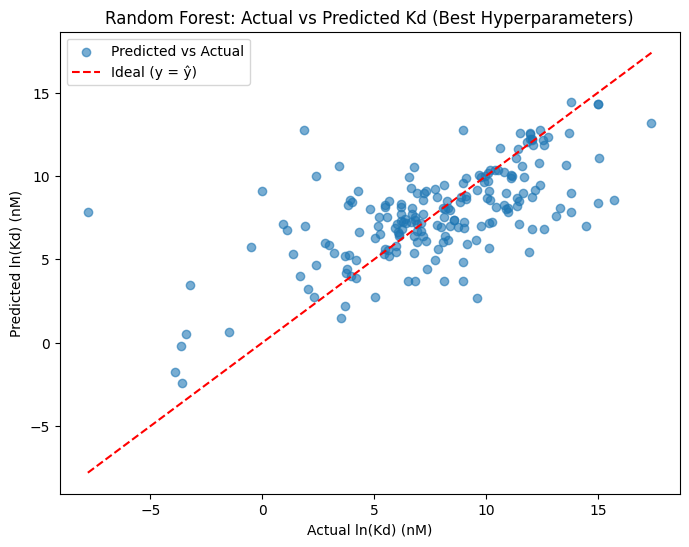

R² score (test set, best model): 0.424
Best hyperparameters:
{'max_depth': np.int64(100), 'min_samples_split': 2, 'n_estimators': np.int64(100)}


In [ ]:
# Plot y_test vs y_pred for best model
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal (y = ŷ)')
plt.xlabel('Actual ln(Kd) (nM)')
plt.ylabel('Predicted ln(Kd) (nM)')
plt.title('Random Forest: Actual vs Predicted Kd (Best Hyperparameters)')
plt.legend()
plt.show()

# Print R² score for best model on test set
r2_best = r2_score(y_test, y_pred)
print(f'R² score (test set, best model): {r2_best:.3f}')

# Print best hyperparameters
print('Best hyperparameters:')
print(grid_search.best_params_)

In [ ]:
# Ensure `best_rf` exists (try memory -> grid_search -> disk). Save it for later sessions.
import os
try:
    # If best_rf already exists in the session, use it
    best_rf  # reference to check existence
    print('best_rf already in memory.')
except NameError:
    # Try to get it from grid_search (if you ran GridSearchCV)
    if 'grid_search' in globals():
        best_rf = grid_search.best_estimator_
        print('Loaded best_rf from grid_search.best_estimator_.')
    else:
        # Try loading from disk
        model_path = 'best_rf.joblib'
        try:
            import joblib
        except Exception:
            raise RuntimeError("joblib not available. Install with: pip install joblib")
        if os.path.exists(model_path):
            best_rf = joblib.load(model_path)
            print(f"Loaded best_rf from '{model_path}'.")
        else:
            raise NameError("best_rf not found in memory, grid_search not present, and 'best_rf.joblib' is missing.\nPlease run the GridSearchCV cell to fit the model, or save a trained model to 'best_rf.joblib'.")
# Persist the model for future sessions (safe to overwrite)
try:
    import joblib
except Exception:
    raise RuntimeError("joblib not available. Install with: pip install joblib")
joblib.dump(best_rf, 'best_rf.joblib')
print("best_rf saved to 'best_rf.joblib'.")

best_rf already in memory.
best_rf saved to 'best_rf.joblib'.
